# Markov decision processes, value iteration and policy iteration

### Planning a route when the rules of the world are handed to you in advance

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to write an MDP down as two arrays, why the Bellman expectation equation is a linear system you can solve with one call to `solve` while the optimality equation is not, how policy iteration and value iteration reach the same answer by different routes, and why value iteration converges at all |
| **You should already know** | Python, NumPy, and what a matrix inverse is for. No prior reinforcement learning needed |
| **Environment** | A 4 by 12 gridworld with its transition model written out in full. No gym, no RL library |
| **Runtime** | Well under two minutes on a laptop CPU |
| **Next** | [11-04 Q-learning](../04-q-learning/) · [11-05 SARSA](../05-sarsa/) |

---

## 1. What changes when you know the dynamics

The previous notebook let an agent loose on a bandit and made it pay for every
scrap of information. The next one, [Q-learning](../04-q-learning/), drops an
agent into a gridworld and lets it walk off a cliff a few hundred times before
it works out where the cliff is.

This notebook is the case in between, and it is the one people skip. Here I am
given the rules. I know, before the agent takes a single step, the probability
of landing in every square from every square under every action, and the reward
that comes with each landing. Nothing has to be sampled. Nothing has to be
estimated.

That turns learning into arithmetic. The question stops being "how do I find out
what this world does" and becomes "given that I already know, what is the best
thing to do". The second question has an exact answer and two clean algorithms
that find it. Both of them are what Q-learning is trying to approximate when it
has no model, and knowing them is the difference between using Q-learning and
understanding it.

### The formalism, written out

A **Markov decision process** is five things.

| | |
|---|---|
| $\mathcal{S}$ | the states. Here, the 48 squares of a 4 by 12 grid |
| $\mathcal{A}$ | the actions. Up, right, down, left |
| $P(s' \mid s, a)$ | the transition model. The chance of landing in $s'$ after taking $a$ in $s$ |
| $R(s, a)$ | the expected reward for taking $a$ in $s$ |
| $\gamma$ | the discount, between 0 and 1. What a reward one step later is worth |

"Markov" is the promise that $P$ depends on the current state and nothing
earlier. Where you came from does not matter, only where you are. That promise
is what makes everything below work, and it is an assumption about the world
rather than a fact about it.

### The grid

I use the same board as [11-04](../04-q-learning/) so the two chapters describe
the same world. Start at the bottom left, goal at the bottom right, and the
squares between them are a cliff.

- Every step costs -1
- Stepping onto the cliff costs -100 and returns you to the start
- Reaching the goal ends the episode

The difference is that the Q-learning agent has to discover all of that from
experience. Here it arrives as two NumPy arrays, and I get to plan.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

ROWS, COLS = 4, 12
N_STATES, N_ACTIONS = ROWS * COLS, 4
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
MOVES = {UP: (-1, 0), RIGHT: (0, 1), DOWN: (1, 0), LEFT: (0, -1)}
ARROWS = {UP: "↑", RIGHT: "→", DOWN: "↓", LEFT: "←"}

START = (ROWS - 1, 0)
GOAL = (ROWS - 1, COLS - 1)
GAMMA = 0.99

VALUE_CMAP = mpl.colormaps["cividis"].with_extremes(bad="#dedede")

### The model as two arrays

`P` has shape (states, actions, states) and `R` has shape (states, actions).
Between them they hold everything there is to know about this world. The point
of the notebook is that these two objects exist, fit in memory, and can be
printed.

I give the builder three switches I will need later: a slip probability, an
optional second exit, and a switch that turns the goal from an ending into a lap
marker. All three are off for now.

In [2]:
def index(cell):
    return cell[0] * COLS + cell[1]


def is_cliff(cell):
    row, col = cell
    return row == ROWS - 1 and 0 < col < COLS - 1


def move(cell, action):
    """Where the agent lands if the move goes as intended. Walls are sticky."""
    d_row, d_col = MOVES[action]
    row = min(max(cell[0] + d_row, 0), ROWS - 1)
    col = min(max(cell[1] + d_col, 0), COLS - 1)
    return row, col


def build_model(slip=0.0, step=-1.0, cliff=-100.0, goal=-1.0,
                door=None, door_cell=(0, 0), recycle=False):
    """Return P with shape (S, A, S) and R with shape (S, A).

    slip     chance the wind takes over and the agent moves at right angles to
             the action it chose, half the time each way. At slip = 0 every
             P[s, a] is a single 1.0 and the world is deterministic.
    door     adds a second terminal square worth `door` points, used in section 5.
    recycle  makes the goal a lap marker instead of an ending: you collect `goal`
             and reappear at the start, so the task never finishes.
    """
    P = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    R = np.zeros((N_STATES, N_ACTIONS))

    terminals = set() if recycle else {index(GOAL)}
    if door is not None:
        terminals.add(index(door_cell))

    for s in range(N_STATES):
        cell = divmod(s, COLS)
        # Absorbing rows with zero reward: terminals, plus the squares the agent
        # can never occupy. They keep P square without affecting any sum.
        if s in terminals or is_cliff(cell) or (recycle and cell == GOAL):
            P[s, :, s] = 1.0
            continue

        for a in range(N_ACTIONS):
            # The two slips are the actions at right angles, which for this
            # ordering of the actions are just the neighbours of a modulo 4.
            for taken, prob in [(a, 1.0 - slip), ((a - 1) % 4, slip / 2), ((a + 1) % 4, slip / 2)]:
                if prob == 0.0:
                    continue
                landed = move(cell, taken)
                if is_cliff(landed):
                    s_next, reward = index(START), cliff
                elif landed == GOAL:
                    s_next, reward = (index(START) if recycle else index(GOAL)), goal
                elif door is not None and landed == door_cell:
                    s_next, reward = index(door_cell), door
                else:
                    s_next, reward = index(landed), step
                P[s, a, s_next] += prob
                R[s, a] += prob * reward

    return P, R


P, R = build_model()

CLIFF_STATES = [index((ROWS - 1, c)) for c in range(1, COLS - 1)]
LIVE_STATES = [s for s in range(N_STATES) if s not in CLIFF_STATES]

print(f"P shape {P.shape}   R shape {R.shape}")
print(f"every row of P sums to 1: {np.allclose(P.sum(axis=2), 1.0)}")
print(f"most negative expected reward, a step onto the cliff: {R.min():.1f}")
print(f"a live square can never end up on the cliff: "
      f"{P[LIVE_STATES][:, :, CLIFF_STATES].sum() == 0.0}")

P shape (48, 4, 48)   R shape (48, 4)
every row of P sums to 1: True
most negative expected reward, a step onto the cliff: -100.0
a live square can never end up on the cliff: True


In [3]:
# The board, printed rather than plotted, so the state numbering stays visible.
for row in range(ROWS):
    line = []
    for col in range(COLS):
        cell = (row, col)
        line.append(" S" if cell == START else
                    " G" if cell == GOAL else
                    " #" if is_cliff(cell) else " .")
    print("".join(line))
print("\nS start, G goal, # cliff. States are numbered row-major, 0 to 47.")

s_probe = index((2, 0))
print(f"\nOne row of the model: state {s_probe}, the square above the start, action RIGHT")
for s_next in np.flatnonzero(P[s_probe, RIGHT]):
    print(f"  lands in state {s_next:2d} = {divmod(s_next, COLS)} "
          f"with probability {P[s_probe, RIGHT, s_next]:.2f}")
print(f"  expected reward R(s, RIGHT) = {R[s_probe, RIGHT]:.2f}")

 . . . . . . . . . . . .
 . . . . . . . . . . . .
 . . . . . . . . . . . .
 S # # # # # # # # # # G

S start, G goal, # cliff. States are numbered row-major, 0 to 47.

One row of the model: state 24, the square above the start, action RIGHT
  lands in state 25 = (np.int64(2), np.int64(1)) with probability 1.00
  expected reward R(s, RIGHT) = -1.00


## 2. The two Bellman equations

A **policy** $\pi$ says which action to take in each state. I write it as an
array of 48 integers.

### The expectation equation

Fix a policy and ask what it is worth. The value of a state under $\pi$ is the
reward you collect now plus the discounted value of wherever you end up:

$$V^\pi(s) = R(s, \pi(s)) + \gamma \sum_{s'} P(s' \mid s, \pi(s))\, V^\pi(s')$$

Collect the rows for the chosen actions into a matrix $P^\pi$ and a vector
$R^\pi$, and the whole system is one line of linear algebra:

$$V^\pi = R^\pi + \gamma P^\pi V^\pi \quad\Longleftrightarrow\quad (I - \gamma P^\pi)\, V^\pi = R^\pi$$

That is 48 equations in 48 unknowns, and it is **linear**. No iteration, no
learning rate, no tolerance to argue about. One call to `np.linalg.solve` and
the policy's exact value is on the table.

It is worth seeing why the inverse exists. $P^\pi$ is a stochastic matrix, so
its spectral radius is 1, and $\gamma P^\pi$ has spectral radius at most
$\gamma < 1$. That makes the Neumann series converge:

$$(I - \gamma P^\pi)^{-1} = \sum_{k=0}^{\infty} \gamma^k (P^\pi)^k$$

and the series is not an algebraic curiosity. Term $k$ is "where you are after
$k$ steps, discounted by $\gamma^k$". The inverse **is** the sum of discounted
future rewards, written as a matrix.

### The optimality equation

Now ask for the best policy rather than the value of a given one:

$$V^*(s) = \max_a \Big[ R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^*(s') \Big]$$

The two equations look almost identical. They are not. The $\max$ picks a
different linear function of $V^*$ depending on which action wins, and which
action wins depends on $V^*$. There is no matrix to invert because there is no
single matrix. There is one per policy, and the choice among them is part of
what I am solving for. Piecewise linear is not linear.

The brute-force escape is real and useless. Every deterministic policy gives a
linear system I could solve exactly, so I could solve all of them and keep the
best.

In [4]:
def evaluate_exact(P, R, pi, gamma):
    """Solve the Bellman expectation equation as the linear system it is."""
    rows = np.arange(N_STATES)
    P_pi, R_pi = P[rows, pi], R[rows, pi]
    return np.linalg.solve(np.eye(N_STATES) - gamma * P_pi, R_pi)


def evaluate_iterative(P, R, pi, gamma, sweeps):
    """The same value, reached by applying the equation to its own output."""
    rows = np.arange(N_STATES)
    P_pi, R_pi = P[rows, pi], R[rows, pi]
    V = np.zeros(N_STATES)
    for _ in range(sweeps):
        V = R_pi + gamma * (P_pi @ V)
    return V


def hand_policy():
    """A route I wrote by hand: climb clear of the cliff row, walk right, drop in."""
    pi = np.full(N_STATES, RIGHT, dtype=int)
    for s in range(N_STATES):
        row, col = divmod(s, COLS)
        if col == COLS - 1:
            pi[s] = DOWN
        elif row > 1:
            pi[s] = UP
    return pi


pi_hand = hand_policy()
V_hand = evaluate_exact(P, R, pi_hand, GAMMA)

print(f"deterministic policies on this grid: {float(N_ACTIONS ** N_STATES):.2e}")
print(f"exact evaluations needed to score one of them: 1\n")
print(f"value of my hand-written route at the start: {V_hand[index(START)]:.4f}")

# That route is 15 steps, every one of them paying -1.
print(f"closed form for a 15-step walk             : {-(1 - GAMMA ** 15) / (1 - GAMMA):.4f}")

deterministic policies on this grid: 7.92e+28
exact evaluations needed to score one of them: 1

value of my hand-written route at the start: -13.9942
closed form for a 15-step walk             : -13.9942


In [5]:
def steps_under(pi, cell, cap=200):
    """How many steps the policy takes from `cell` to the goal, or cap if never."""
    for k in range(1, cap + 1):
        cell = move(cell, int(pi[index(cell)]))
        if is_cliff(cell):
            cell = START
        if cell == GOAL:
            return k
    return cap


horizon = max(steps_under(pi_hand, divmod(s, COLS))
              for s in LIVE_STATES if divmod(s, COLS) != GOAL)

rows = []
for sweeps in [1, 3, 5, 10, 14, 15, 16, 40]:
    gap = np.abs(evaluate_iterative(P, R, pi_hand, GAMMA, sweeps) - V_hand).max()
    rows.append({"sweeps": sweeps, "max gap to the exact solve": gap})

print(f"longest route this policy takes to the goal: {horizon} steps\n")
print(pd.DataFrame(rows).to_string(index=False,
                                   formatters={"max gap to the exact solve": "{:.2e}".format}))

longest route this policy takes to the goal: 15 steps

 sweeps max gap to the exact solve
      1                   1.30e+01
      3                   1.10e+01
      5                   9.09e+00
     10                   4.43e+00
     14                   8.69e-01
     15                   3.55e-15
     16                   3.55e-15
     40                   3.55e-15


The iterative version does not creep toward the answer forever. It lands on it,
and then stops moving, at floating point noise.

The reason is worth keeping. Each sweep carries reward information backwards
exactly one square. Once the number of sweeps covers the longest route the
policy takes, every state has heard from the goal and there is nothing left to
propagate. This is special to a world where episodes end and nothing is random.
Section 4 shows what happens when neither of those holds.

## 3. Policy iteration

Policy iteration is the obvious idea, made precise. Two steps, alternating.

**Policy evaluation.** Given $\pi$, solve $(I - \gamma P^\pi) V^\pi = R^\pi$ for
what it is worth.

**Policy improvement.** Given $V^\pi$, look one step ahead from every state and
switch to the action that comes out best:

$$\pi'(s) = \arg\max_a \Big[ R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V^\pi(s') \Big]$$

The **policy improvement theorem** says $V^{\pi'} \ge V^{\pi}$ in every state,
strictly better somewhere unless $\pi$ was already optimal. So each round
produces a policy strictly better than the last, and a policy that has been
visited can never come back.

That gives a termination argument, and it is unusually satisfying for this
corner of machine learning. There are finitely many deterministic policies. The
sequence never repeats one. Therefore it stops, after finitely many rounds, at a
policy that no one-step change can improve, which by the optimality equation is
the optimal policy. Not "converges in the limit". Stops.

In [6]:
def greedy(P, R, V, gamma):
    """One-step lookahead. Returns the greedy policy and the full Q table."""
    Q = R + gamma * (P.reshape(N_STATES * N_ACTIONS, N_STATES) @ V).reshape(N_STATES, N_ACTIONS)
    return Q.argmax(axis=1), Q


def policy_iteration(P, R, gamma, max_rounds=500):
    pi = np.zeros(N_STATES, dtype=int)          # start from "always up", a bad plan
    rows = np.arange(N_STATES)
    history = []

    for round_no in range(1, max_rounds + 1):
        V = evaluate_exact(P, R, pi, gamma)
        _, Q = greedy(P, R, V, gamma)

        # Switch only where the switch strictly helps. Keeping the old action on
        # a tie is what stops the sequence of policies from ever cycling.
        better = Q.max(axis=1) > Q[rows, pi] + 1e-12
        history.append({"round": round_no,
                        "V(start)": V[index(START)],
                        "actions changed": int(better.sum())})
        if not better.any():
            return pi, V, pd.DataFrame(history)
        pi = np.where(better, Q.argmax(axis=1), pi)

    raise RuntimeError("policy iteration did not settle")


pi_star, V_star, pi_history = policy_iteration(P, R, GAMMA)

print(pi_history.to_string(index=False, formatters={"V(start)": "{:.4f}".format}))
print(f"\npolicy iteration settled after {len(pi_history)} rounds")
print(f"optimal value at the start : {V_star[index(START)]:.4f}")
print(f"my hand-written route      : {V_hand[index(START)]:.4f}")

 round  V(start)  actions changed
     1 -100.0000                1
     2 -100.0000                2
     3 -100.0000                3
     4 -100.0000                3
     5 -100.0000                3
     6 -100.0000                3
     7 -100.0000                3
     8 -100.0000                3
     9 -100.0000                3
    10 -100.0000                3
    11 -100.0000                3
    12 -100.0000                3
    13  -12.2479                2
    14  -12.2479                1
    15  -12.2479                0

policy iteration settled after 15 rounds
optimal value at the start : -12.2479
my hand-written route      : -13.9942


### What the answer looks like

The value function is one number per square: what that square is worth if you
play well from there onward. The policy is one arrow per square. Drawing the
arrows on top of the values shows what the arrows are made of. They point
uphill, always.

route the optimal policy takes : 13 steps
shortest route the grid allows : 13 steps
values run from -13.13 to 0.00


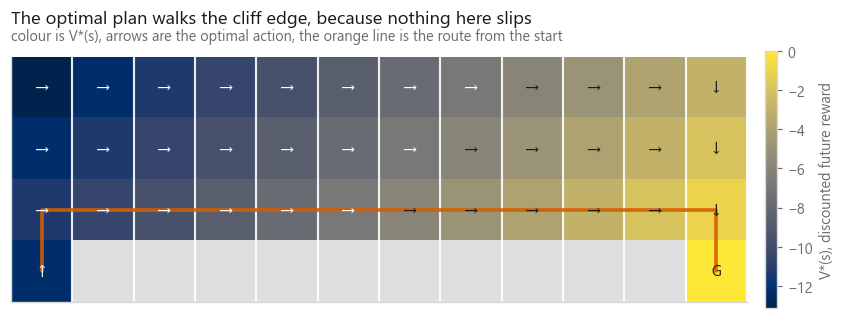

In [7]:
def intended_route(pi, max_steps=80, door_cell=None):
    """Follow the policy with the noise switched off, to draw the route it means."""
    cell = START
    path = [cell]
    for _ in range(max_steps):
        cell = move(cell, int(pi[index(cell)]))
        if is_cliff(cell):
            cell = START
        path.append(cell)
        if cell == GOAL or (door_cell is not None and cell == door_cell):
            break
    return path


def decorate(ax):
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.4)
    ax.tick_params(which="both", length=0, labelbottom=False, labelleft=False)
    ax.grid(which="major", visible=False)


def draw_route(ax, pi, door_cell=None, path=None):
    # `path` lets the caller supply a route drawn some other way. A policy that
    # deliberately leans on the noise has no sensible noise-free route, and the
    # slippery section below runs into exactly that.
    if path is None:
        path = intended_route(pi, door_cell=door_cell)
    ax.plot([c for _, c in path], [r for r, _ in path], color=style.HIGHLIGHT,
            lw=2.4, alpha=0.9, solid_capstyle="round")
    return len(path) - 1


def draw_values(ax, V, pi, headline, sub=None):
    grid = V.reshape(ROWS, COLS).astype(float).copy()
    grid[ROWS - 1, 1:COLS - 1] = np.nan          # the cliff has no value to show
    im = ax.imshow(np.ma.masked_invalid(grid), cmap=VALUE_CMAP)

    # Cividis runs dark to light, so the arrow ink has to follow the cell.
    lo, hi = np.nanmin(grid), np.nanmax(grid)
    for s in range(N_STATES):
        row, col = divmod(s, COLS)
        if is_cliff((row, col)) or (row, col) == GOAL:
            continue
        shade = (grid[row, col] - lo) / (hi - lo)
        ax.text(col, row, ARROWS[int(pi[s])], ha="center", va="center",
                fontsize=12, color="white" if shade < 0.55 else style.INK)

    ax.text(GOAL[1], GOAL[0], "G", ha="center", va="center", fontsize=9.5, color=style.INK)
    steps = draw_route(ax, pi)
    decorate(ax)
    style.title(ax, headline, sub)
    return im, steps


fig, ax = plt.subplots(figsize=(10.4, 3.7))
im, steps = draw_values(
    ax, V_star, pi_star,
    "The optimal plan walks the cliff edge, because nothing here slips",
    "colour is V*(s), arrows are the optimal action, the orange line is the route from the start")
cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label("V*(s), discounted future reward", fontsize=9.5, color=style.MUTED)
style.save(fig, FIG / "fig-01-optimal-value-and-policy.png")

print(f"route the optimal policy takes : {steps} steps")
print(f"shortest route the grid allows : 13 steps")
print(f"values run from {V_star[LIVE_STATES].min():.2f} to {V_star[LIVE_STATES].max():.2f}")

Every arrow points along the steepest climb in the value surface, which is the
whole content of "greedy with respect to $V^*$". The route hugs the cliff
because in a world with no noise, hugging the cliff is free and saves two steps.
Section 5 takes that assumption away.

## 4. Value iteration, and why it converges

Policy iteration solves a 48 by 48 system every round to get $V^\pi$ exactly,
then throws most of that precision away the moment it takes an `argmax`. Value
iteration asks whether the exact solve was ever needed.

It is not. One sweep is enough. Apply the optimality equation as an assignment
and repeat:

$$V_{k+1}(s) \leftarrow \max_a \Big[ R(s, a) + \gamma \sum_{s'} P(s' \mid s, a)\, V_k(s') \Big]$$

No policy is stored at all. It falls out at the end by reading off the `argmax`
once.

### Why it works

Call that update $T$. The claim is that $T$ is a **contraction** in the max
norm: for any two value functions,

$$\|TV - TU\|_\infty \le \gamma \|V - U\|_\infty$$

The proof is short. In any state, $\max_a f(a) - \max_a g(a)$ is at most
$\max_a\,(f(a) - g(a))$, so the difference after an update is at most
$\gamma \sum_{s'} P(s'|s,a)\,|V(s') - U(s')|$, and a weighted average of numbers
is at most the largest of them. The $\gamma$ survives, everything else
collapses.

Banach's fixed point theorem then hands over the rest at once: a unique fixed
point, which must be $V^*$ because $V^*$ satisfies the equation, and convergence
to it from any starting point at a geometric rate. Concretely, the change
between consecutive sweeps shrinks by a factor of at least $\gamma$ every time:

$$\|V_{k+1} - V_k\|_\infty \le \gamma \|V_k - V_{k-1}\|_\infty$$

That is a prediction with a number in it, so I can plot it against what actually
happens.

In [8]:
def value_iteration(P, R, gamma, tol=1e-10, max_sweeps=50_000, record=False):
    V = np.zeros(N_STATES)
    deltas, trace = [], []

    for _ in range(max_sweeps):
        _, Q = greedy(P, R, V, gamma)
        V_next = Q.max(axis=1)
        delta = np.abs(V_next - V).max()
        V = V_next
        deltas.append(delta)
        if record:
            trace.append(V.copy())
        if delta < tol:
            break

    pi, _ = greedy(P, R, V, gamma)
    return pi, V, np.array(deltas), (np.array(trace) if record else None)


pi_vi, V_vi, deltas_ep, _ = value_iteration(P, R, GAMMA, record=False)

print(f"value iteration sweeps  : {len(deltas_ep)}")
print(f"policy iteration rounds : {len(pi_history)}")
print(f"last change recorded    : {deltas_ep[-1]:.1e}")
print(f"max gap between the two value functions : {np.abs(V_vi - V_star).max():.3e}")
print(f"states where the two policies differ    : {int((pi_vi != pi_star).sum())}")
print(f"gap between what those two policies are worth : "
      f"{np.abs(evaluate_exact(P, R, pi_vi, GAMMA) - V_star).max():.3e}")

value iteration sweeps  : 15
policy iteration rounds : 15
last change recorded    : 0.0e+00
max gap between the two value functions : 3.553e-15
states where the two policies differ    : 0
gap between what those two policies are worth : 0.000e+00


Two policies can differ and still be worth the same, which is what a tie looks
like: two routes of equal length, and each algorithm breaks the tie its own way.

The sweep count is the surprise. The contraction bound at this discount predicts
a long grind, and the run is over in a handful of sweeps. The reason is the one
from section 2: this world ends. Once every square has heard from the goal, the
values are exact and the changes are genuinely zero rather than merely small.

So to see the contraction rate itself I need a world that never ends. I take the
same board and turn the goal into a lap marker: reach it, collect a bonus, and
reappear at the start. Nothing else changes, and now there is no horizon for the
sweeps to run out of.

In [9]:
cont_P, cont_R = build_model(goal=50.0, recycle=True)
pi_cont, V_cont, deltas_cont, trace_cont = value_iteration(cont_P, cont_R, GAMMA, record=True)

# Policy iteration gives the exact V* here, which is the yardstick the sweeps of
# value iteration get measured against below.
_, V_cont_star, _ = policy_iteration(cont_P, cont_R, GAMMA)

print(f"sweeps on the episodic board   : {len(deltas_ep)}")
print(f"sweeps on the continuing board : {len(deltas_cont)}")
print(f"value at the start, continuing : {V_cont[index(START)]:.2f} "
      f"(a lap is worth 50 and repeats forever)")
print(f"value iteration against the exact solve: {np.abs(V_cont - V_cont_star).max():.2e}")

sweeps on the episodic board   : 15
sweeps on the continuing board : 2682
value at the start, continuing : 269.09 (a lap is worth 50 and repeats forever)
value iteration against the exact solve: 6.22e-10


predicted contraction factor  : 0.99
measured, median across sweeps: 0.990000
sweeps the bound predicts     : 2681
sweeps actually taken         : 2682
true distance to V* over change per sweep, at the last sweep: 6.3   (the bound allows 99.0)


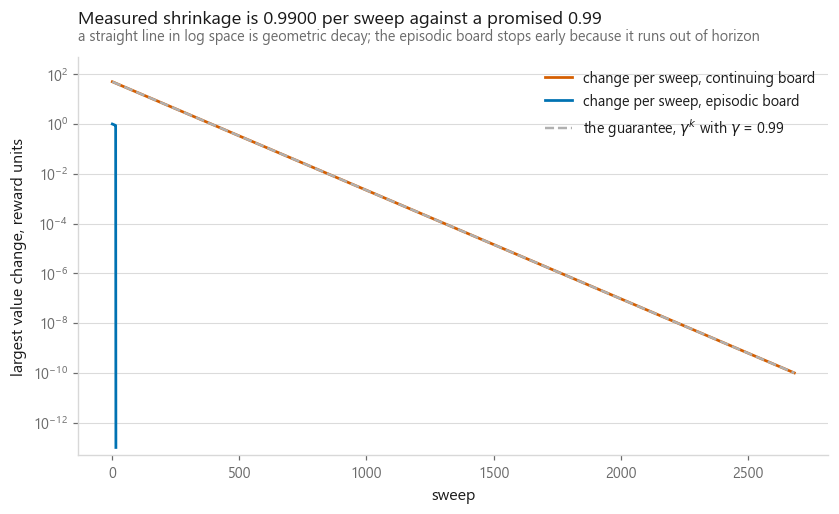

In [10]:
errors = np.abs(trace_cont - V_cont_star).max(axis=1)
k_cont = np.arange(1, len(deltas_cont) + 1)
bound = deltas_cont[0] * GAMMA ** (k_cont - 1)

# Measured shrinkage, away from the first sweeps that are still filling in zeros
# and the last that sit in floating point noise.
ratios = deltas_cont[1:] / deltas_cont[:-1]
measured = float(np.median(ratios[20:len(ratios) - 20]))

FLOOR = 1e-13
fig, ax = plt.subplots(figsize=(8.8, 4.7))
ax.semilogy(k_cont, np.maximum(deltas_cont, FLOOR), color=style.HIGHLIGHT, lw=1.8,
            label="change per sweep, continuing board")
ax.semilogy(np.arange(1, len(deltas_ep) + 1), np.maximum(deltas_ep, FLOOR),
            color=style.PALETTE[0], lw=1.8, label="change per sweep, episodic board")
ax.semilogy(k_cont, bound, color=style.NEUTRAL, lw=1.6, ls="--",
            label=f"the guarantee, $\\gamma^k$ with $\\gamma$ = {GAMMA}")
ax.set_xlabel("sweep")
ax.set_ylabel("largest value change, reward units")
ax.set_ylim(FLOOR / 2, 5e2)
ax.legend(loc="upper right")
style.title(ax,
            f"Measured shrinkage is {measured:.4f} per sweep against a promised {GAMMA}",
            "a straight line in log space is geometric decay; the episodic board "
            "stops early because it runs out of horizon")
style.save(fig, FIG / "fig-02-contraction.png")

print(f"predicted contraction factor  : {GAMMA}")
print(f"measured, median across sweeps: {measured:.6f}")
print(f"sweeps the bound predicts     : "
      f"{int(np.ceil(np.log(1e-10 / deltas_cont[0]) / np.log(GAMMA)))}")
print(f"sweeps actually taken         : {len(deltas_cont)}")
print(f"true distance to V* over change per sweep, at the last sweep: "
      f"{errors[-1] / deltas_cont[-1]:.1f}   (the bound allows "
      f"{GAMMA / (1 - GAMMA):.1f})")

The continuing board runs parallel to the guaranteed line rather than falling
away from it, which says the bound is tight rather than pessimistic once the
task has no end. The episodic board leaves the line altogether, and that gap is
the whole reason value iteration is usable on real problems: the worst case
assumes value has to seep across the state space forever, and a task that
terminates cuts the seepage short.

The practical consequence of the rate is in the exponent. Sweeps needed scale
like $\log(\text{tol}) / \log \gamma$, so moving $\gamma$ from 0.9 toward 1 does
not cost a little more work, it costs an order of magnitude more.

One more warning is in the printout above. The distance to $V^*$ is larger than
the change per sweep, and the standard bound relating them is
$\|V_k - V^*\|_\infty \le \frac{\gamma}{1-\gamma}\|V_k - V_{k-1}\|_\infty$. At a
discount near 1 that leading factor is large, so a small change per sweep is
weaker evidence of being finished than it looks.

### The circularity, made concrete

Two checks that say the same thing from opposite ends. First, $V^*$ satisfies
the optimality equation to machine precision, so the `max` really does close on
itself. Second, if I take the optimal policy and solve the **linear** system for
it, I get $V^*$ back.

So the optimality equation does collapse to a linear solve, on one condition:
you have to already know $\pi^*$. Finding $\pi^*$ is the entire problem, which is
why the collapse buys nothing, and why both algorithms in this notebook exist.

In [11]:
_, Q_star = greedy(P, R, V_vi, GAMMA)

print(f"optimality residual, max |max_a Q*(s,a) - V*(s)|          : "
      f"{np.abs(Q_star.max(axis=1) - V_vi).max():.3e}")
print(f"linear solve for pi*, max gap to V* from value iteration  : "
      f"{np.abs(evaluate_exact(P, R, pi_star, GAMMA) - V_star).max():.3e}")

optimality residual, max |max_a Q*(s,a) - V*(s)|          : 0.000e+00
linear solve for pi*, max gap to V* from value iteration  : 0.000e+00


### Policy iteration against value iteration, measured

Policy iteration does expensive rounds and few of them. Value iteration does
cheap sweeps and many of them. Which one wins is an empirical question, and the
answer moves with the discount and with whether the task ends.

In [12]:
def timed(fn, repeats=5):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return out, best


bench = []
for name, (Pm, Rm) in [("episodic", (P, R)), ("continuing", (cont_P, cont_R))]:
    for gamma in [0.90, 0.95, 0.99]:
        (_, V_a, hist), t_pi = timed(lambda M=Pm, N=Rm, g=gamma: policy_iteration(M, N, g))
        (_, V_b, d_b, _), t_vi = timed(lambda M=Pm, N=Rm, g=gamma: value_iteration(M, N, g))
        bench.append({"board": name, "gamma": gamma,
                      "PI rounds": len(hist), "VI sweeps": len(d_b),
                      "PI ms": t_pi * 1e3, "VI ms": t_vi * 1e3,
                      "value gap": float(np.abs(V_a - V_b).max())})

bench = pd.DataFrame(bench)
print(bench.to_string(index=False, formatters={"PI ms": "{:.2f}".format,
                                               "VI ms": "{:.2f}".format,
                                               "value gap": "{:.1e}".format}))

iter_ratio = bench["VI sweeps"] / bench["PI rounds"]
time_ratio = bench["VI ms"] / bench["PI ms"]

     board  gamma  PI rounds  VI sweeps PI ms VI ms value gap
  episodic   0.90         15         15  1.73  0.30   1.8e-15
  episodic   0.95         15         15  1.77  0.29   0.0e+00
  episodic   0.99         15         15  1.74  0.30   3.6e-15
continuing   0.90         15        257  1.38  3.11   1.0e-10
continuing   0.95         15        527  1.62 10.11   1.5e-10
continuing   0.99         15       2682  1.57 49.34   6.2e-10


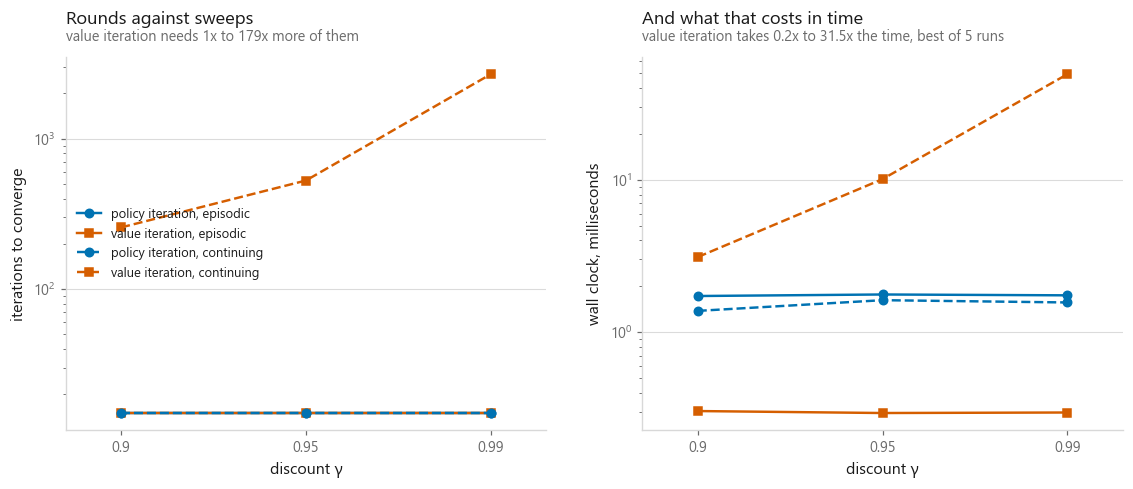

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
x = np.arange(3)
panels = [("PI rounds", "VI sweeps", "iterations to converge",
           "Rounds against sweeps",
           f"value iteration needs {iter_ratio.min():.0f}x to {iter_ratio.max():.0f}x more of them"),
          ("PI ms", "VI ms", "wall clock, milliseconds",
           "And what that costs in time",
           f"value iteration takes {time_ratio.min():.1f}x to {time_ratio.max():.1f}x "
           f"the time, best of 5 runs")]

for ax, (col_pi, col_vi, ylabel, headline, sub) in zip(axes, panels):
    for j, board in enumerate(["episodic", "continuing"]):
        sub_df = bench[bench["board"] == board]
        ax.plot(x, sub_df[col_pi].to_numpy(), color=style.PALETTE[0], ls=["-", "--"][j],
                marker=style.MARKERS[0], lw=1.6, label=f"policy iteration, {board}")
        ax.plot(x, sub_df[col_vi].to_numpy(), color=style.HIGHLIGHT, ls=["-", "--"][j],
                marker=style.MARKERS[1], lw=1.6, label=f"value iteration, {board}")
    ax.set_yscale("log")
    ax.set_xticks(x, [f"{g:g}" for g in [0.90, 0.95, 0.99]])
    ax.set_xlabel("discount γ")
    ax.set_ylabel(ylabel)
    ax.set_xlim(-0.3, 2.3)
    style.title(ax, headline, sub)

axes[0].legend(fontsize=8.5, loc="center left")
style.save(fig, FIG / "fig-03-policy-vs-value-iteration.png")

Policy iteration wins on both counts on a grid this size, and the margin widens
as the discount rises. The reason is that the exact solve does in one step what
value iteration needs a full geometric decay to accomplish: it propagates value
across the whole grid at once, rather than one square per sweep.

Nobody uses policy iteration on large problems, and the reason is the cube in
that solve. At 48 states a dense factorisation is free. At a million states it
is impossible, while a value iteration sweep stays linear in the number of
transitions. The crossover is a property of the problem size, not of the
algorithms.

## 5. Discount and stochastic dynamics

Two things that change the answer itself, rather than the speed of reaching it.

### The discount decides how far ahead the agent bothers to look

$\gamma$ multiplies a reward $k$ steps away by $\gamma^k$. At 0.99 that is a
gentle taper. At 0.5 a reward on the far side of the board has been divided down
into invisibility and may as well not be there.

To make that visible the agent needs something to give up, so for this
experiment only I change the payoffs: the goal now pays +100, and there is a
**side door** in the top left corner, three steps from the start, paying +25.
Both end the episode. A patient agent should walk to the goal. A short-sighted
one should take the money by the entrance and go home.

In [14]:
DOOR_CELL = (0, 0)
door_P, door_R = build_model(goal=100.0, door=25.0, door_cell=DOOR_CELL)


def route_end(pi):
    end = intended_route(pi, door_cell=DOOR_CELL)[-1]
    return "goal" if end == GOAL else ("side door" if end == DOOR_CELL else "neither")


sweep = []
for gamma in np.round(np.arange(0.50, 1.00, 0.02), 2):
    pi_g, V_g, _ = policy_iteration(door_P, door_R, float(gamma))
    sweep.append({"gamma": float(gamma), "exit taken": route_end(pi_g),
                  "steps": len(intended_route(pi_g, door_cell=DOOR_CELL)) - 1,
                  "V(start)": V_g[index(START)]})

sweep = pd.DataFrame(sweep)
patient = sweep.loc[sweep["exit taken"] == "goal", "gamma"]
switch_gamma = float(patient.min()) if len(patient) else float("nan")

print(sweep.to_string(index=False, formatters={"V(start)": "{:.3f}".format}))
print(f"\nthe far goal first wins at gamma = {switch_gamma:.2f}")

 gamma exit taken  steps V(start)
  0.50  side door      3    4.750
  0.52  side door      3    5.240
  0.54  side door      3    5.750
  0.56  side door      3    6.280
  0.58  side door      3    6.830
  0.60  side door      3    7.400
  0.62  side door      3    7.990
  0.64  side door      3    8.600
  0.66  side door      3    9.230
  0.68  side door      3    9.880
  0.70  side door      3   10.550
  0.72  side door      3   11.240
  0.74  side door      3   11.950
  0.76  side door      3   12.680
  0.78  side door      3   13.430
  0.80  side door      3   14.200
  0.82  side door      3   14.990
  0.84  side door      3   15.800
  0.86  side door      3   16.630
  0.88  side door      3   17.480
  0.90       goal     13   21.067
  0.92       goal     13   28.862
  0.94       goal     13   38.857
  0.96       goal     13   51.589
  0.98       goal     13   67.708

the far goal first wins at gamma = 0.90


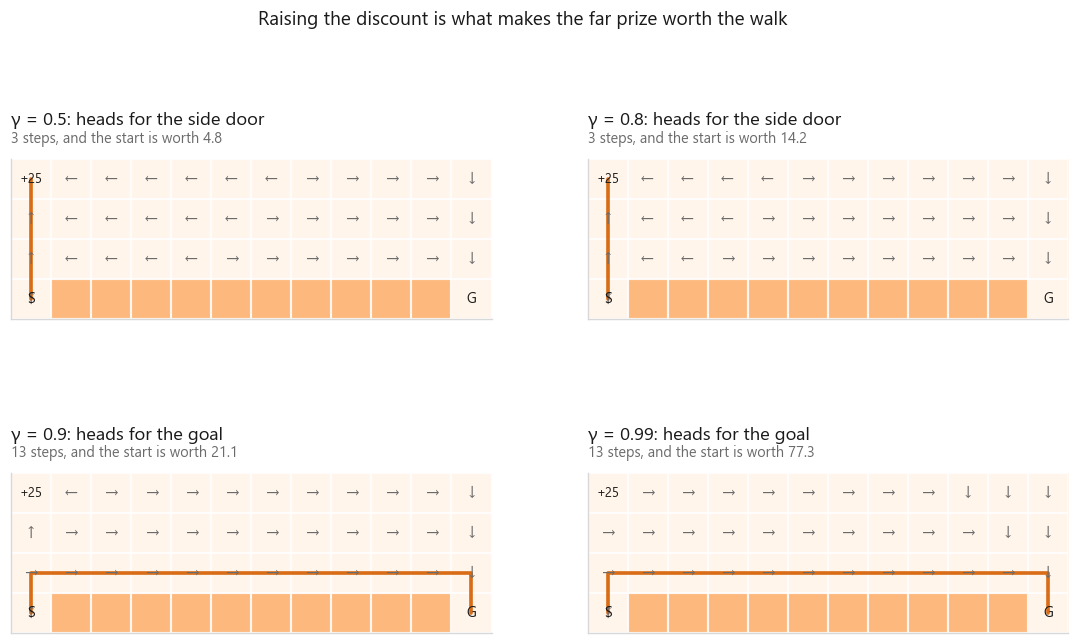

In [15]:
def draw_policy(ax, pi, headline, sub=None, door_cell=None, path=None):
    board = np.zeros((ROWS, COLS))
    board[ROWS - 1, 1:COLS - 1] = 1.0
    ax.imshow(board, cmap="Oranges", vmin=0, vmax=3.0)

    for s in range(N_STATES):
        cell = divmod(s, COLS)
        if is_cliff(cell) or cell == GOAL or cell == door_cell:
            continue
        ax.text(cell[1], cell[0], ARROWS[int(pi[s])], ha="center", va="center",
                fontsize=11.5, color=style.MUTED)

    ax.text(START[1], START[0], "S", ha="center", va="center", fontsize=9.5, color=style.INK)
    ax.text(GOAL[1], GOAL[0], "G", ha="center", va="center", fontsize=9.5, color=style.INK)
    if door_cell is not None:
        ax.text(door_cell[1], door_cell[0], "+25", ha="center", va="center",
                fontsize=8.5, color=style.INK)

    steps = draw_route(ax, pi, door_cell=door_cell, path=path)
    decorate(ax)
    style.title(ax, headline, sub)
    return steps


fig, axes = plt.subplots(2, 2, figsize=(12.4, 6.8))
for ax, gamma in zip(axes.ravel(), [0.50, 0.80, 0.90, 0.99]):
    pi_g, V_g, _ = policy_iteration(door_P, door_R, gamma)
    n_steps = len(intended_route(pi_g, door_cell=DOOR_CELL)) - 1
    draw_policy(ax, pi_g, f"γ = {gamma:g}: heads for the {route_end(pi_g)}",
                f"{n_steps} steps, and the start is worth {V_g[index(START)]:.1f}",
                door_cell=DOOR_CELL)

fig.suptitle("Raising the discount is what makes the far prize worth the walk",
             x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-discount-sweep.png")

I expected the discount to push the agent off the cliff edge as well, reasoning
that a short-sighted agent would grab the short dangerous route and a patient
one would pay for safety. It does not, and the reason is worth stating plainly:
on this board the cliff penalty arrives **immediately**. Discounting only shrinks
costs that lie in the future, so an impatient agent fears the cliff exactly as
much as a patient one does. Below is the check.

In [16]:
for gamma in [0.5, 0.7, 0.9, 0.99]:
    pi_g, _, _ = policy_iteration(P, R, gamma)
    path = intended_route(pi_g)
    edge = sum(1 for r, c in path if r == ROWS - 2 and 0 < c < COLS - 1)
    print(f"gamma {gamma:<5}: route is {len(path) - 1} steps, {edge} of them "
          f"on the row directly above the cliff")

gamma 0.5  : route is 13 steps, 10 of them on the row directly above the cliff
gamma 0.7  : route is 13 steps, 10 of them on the row directly above the cliff
gamma 0.9  : route is 13 steps, 10 of them on the row directly above the cliff
gamma 0.99 : route is 13 steps, 10 of them on the row directly above the cliff


What moves the route away from the edge is not impatience. It is doubt about
where your feet will land.

### Slippery dynamics

Now I rebuild the model with a slip probability. The chosen action still happens
most of the time, but occasionally the agent travels at right angles to it
instead, half the time each way. Not a line of the algorithms changes. `P` stops
being a permutation matrix per action and the same code runs.

This is where having the model earns its keep. The agent does not have to fall
off the cliff to learn that walking beside it is dangerous. The danger is
already written into $P$, and a single lookahead finds it.

In [17]:
SLIP = 0.2
slip_P, slip_R = build_model(slip=SLIP)
pi_slip, V_slip, _ = policy_iteration(slip_P, slip_R, GAMMA)

# What does the confident plan cost if you actually run it in the slippery world?
V_naive = evaluate_exact(slip_P, slip_R, pi_star, GAMMA)

print(f"slip probability {SLIP:.2f}, split evenly between the two right angles\n")
print(f"start value, slip-aware plan run in the slippery world : {V_slip[index(START)]:.2f}")
print(f"start value, cliff-edge plan run in the slippery world : {V_naive[index(START)]:.2f}")
print(f"start value, cliff-edge plan run in the clean world    : {V_star[index(START)]:.2f}")

slip probability 0.20, split evenly between the two right angles

start value, slip-aware plan run in the slippery world : -25.48
start value, cliff-edge plan run in the slippery world : -129.10
start value, cliff-edge plan run in the clean world    : -12.25


I went to draw the slip-aware route the same way I drew every other route in
this notebook, by following the policy with the noise switched off. It never
moved. Eighty steps, all of them on the starting square.

The reason is the best thing on this board, so here is the policy's own first
move next to the confident one:

In [18]:
NAMES = ["up", "right", "down", "left"]
print(f"first move from the start square, cliff-edge plan : "
      f"{NAMES[int(pi_star[index(START)])]}")
print(f"first move from the start square, slip-aware plan : "
      f"{NAMES[int(pi_slip[index(START)])]}\n")

# Where does each candidate action actually put you, under slip?
#
# Reading this off P would report zero cliff risk for every action, because P
# already redirects a fall to the start square and no probability is left sitting
# on a cliff state. The risk is in the transition, not the destination, so the
# slip has to be re-applied against the move rule to see it.
for a, name in enumerate(NAMES):
    onto_cliff = upward = 0.0
    for taken, prob in [(a, 1.0 - SLIP), ((a - 1) % 4, SLIP / 2), ((a + 1) % 4, SLIP / 2)]:
        landed = move(START, taken)
        if is_cliff(landed):
            onto_cliff += prob
        elif landed[0] < START[0]:
            upward += prob
    print(f"  press {name:5s}: P(over the cliff) = {onto_cliff:.2f}   "
          f"P(move up) = {upward:.2f}")

first move from the start square, cliff-edge plan : up
first move from the start square, slip-aware plan : left

  press up   : P(over the cliff) = 0.10   P(move up) = 0.80
  press right: P(over the cliff) = 0.80   P(move up) = 0.10
  press down : P(over the cliff) = 0.10   P(move up) = 0.00
  press left : P(over the cliff) = 0.00   P(move up) = 0.10


The slip-aware plan presses **left, into the wall**.

Walking into a wall does nothing, which is why the noise-free rollout stood
still. Under slip it does something the other three actions cannot. The
intended move is absorbed by the wall, and the two ways the agent can slip off
it are the right angles to left, which are up and down. Down is another wall.
Up is free progress. So pressing into the wall has no chance at all of reaching
the cliff, and a real chance of getting where the agent wants to go.

Pressing up, the move that looks correct, slips sideways onto the cliff.

The two are not close. Pressing up climbs eight times more often per attempt.
It also carries a cliff risk on every attempt, and a fall costs a hundred
against a step's one. At those prices the agent would rather stand at the wall
and wait to be pushed.

The agent has found a way to use the wall as a filter: it points at the one
direction where the noise can only help it, and lets the noise do the moving.
Nothing in the code knows what a wall is. It fell out of a lookahead over $P$.

It also means "the route this policy intends" is not a well-defined thing to
draw. A policy that leans on the noise has to be watched in the world it was
built for, so below I roll both plans out under the slippery dynamics.

In [19]:
def walk(pi, rng, slip=SLIP, cap=400):
    """Run a policy in the slippery world, one step at a time.

    P sends a cliff step straight back to the start, so a fall leaves no trace
    in the state sequence. Re-applying the slip here means the fall is visible.
    """
    cell, path, falls, edge = START, [START], 0, 0
    for _ in range(cap):
        intended = int(pi[index(cell)])
        taken = rng.choice([intended, (intended - 1) % 4, (intended + 1) % 4],
                           p=[1.0 - slip, slip / 2, slip / 2])
        landed = move(cell, taken)
        if is_cliff(landed):
            falls += 1
            landed = START
        cell = landed
        path.append(cell)
        if cell[0] == ROWS - 2 and 0 < cell[1] < COLS - 1:
            edge += 1
        if cell == GOAL:
            break
    return path, falls, edge


def summarise(pi, runs=2000):
    rng = np.random.default_rng(0)
    stats = np.array([[len(p) - 1, f, e]
                      for p, f, e in (walk(pi, rng) for _ in range(runs))])
    return stats.mean(axis=0)


rows = []
for label, pi in [("cliff-edge plan", pi_star), ("slip-aware plan", pi_slip)]:
    steps, falls, edge = summarise(pi)
    rows.append({"plan run in the slippery world": label, "mean steps": steps,
                 "mean falls": falls, "steps beside the cliff": edge})
slippery = pd.DataFrame(rows)
print(slippery.to_string(index=False, float_format="{:.2f}".format))

plan run in the slippery world  mean steps  mean falls  steps beside the cliff
               cliff-edge plan       24.43        1.22                    9.30
               slip-aware plan       30.16        0.00                    1.33


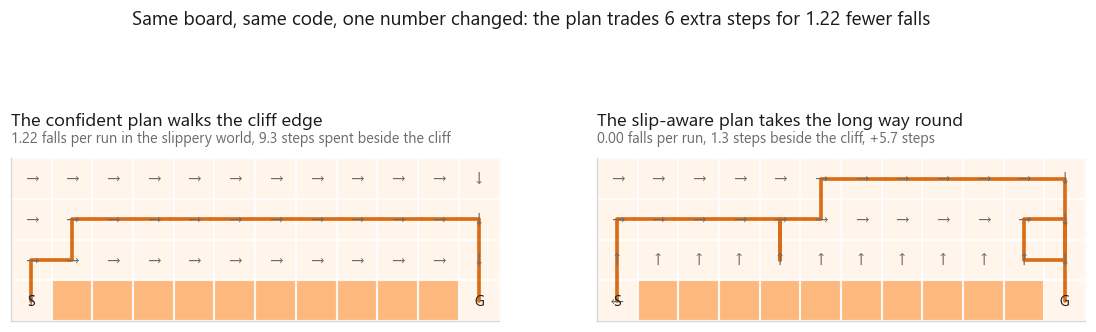

In [20]:
det_path, _, _ = walk(pi_star, np.random.default_rng(3))
slip_path, _, _ = walk(pi_slip, np.random.default_rng(3))
det_steps, det_falls, det_edge = summarise(pi_star)
slip_steps, slip_falls, slip_edge = summarise(pi_slip)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 3.9))
draw_policy(
    axes[0], pi_star, "The confident plan walks the cliff edge",
    f"{det_falls:.2f} falls per run in the slippery world, "
    f"{det_edge:.1f} steps spent beside the cliff", path=det_path)
draw_policy(
    axes[1], pi_slip, "The slip-aware plan takes the long way round",
    f"{slip_falls:.2f} falls per run, {slip_edge:.1f} steps beside the cliff, "
    f"{slip_steps - det_steps:+.1f} steps", path=slip_path)
fig.suptitle(
    f"Same board, same code, one number changed: the plan trades "
    f"{slip_steps - det_steps:.0f} extra steps for {det_falls - slip_falls:.2f} fewer falls",
    x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-05-deterministic-vs-slippery.png")

One line of that table is worth pausing on: the confident plan is **faster**.
It reaches the goal in fewer steps than the careful one, because the route
along the cliff edge is the short route and most of the time it works. What it
also does is fall, and every fall costs a hundred and puts the agent back at
the start. The careful plan pays a few extra steps and buys the falls away.

If you were watching step counts alone you would pick the wrong plan. The
reward function is what tells them apart, and the value at the start square is
where that shows up.

Running the confident plan in the slippery world is the expensive mistake: it
walks the edge because its model said the edge was free. A plan is only as good
as the model behind it, and a model that is confident and wrong is worse than
one that admits noise.

If those two policies look familiar, they should. It is the same split that
[11-04](../04-q-learning/) produces between Q-learning and SARSA, one policy on
the edge and one with clearance, arrived at from the opposite direction. There
the difference came from whether the agent's own random exploration was counted
in its estimates. Here it comes from whether the noise was written into $P$.
Both are the same question: does the plan account for the ways the agent will
fail to do what it intended.

### What Q-learning is approximating

Put the two updates side by side.

$$\text{value iteration:}\quad V(s) \leftarrow \max_a \Big[ R(s,a) + \gamma \sum_{s'} P(s'\mid s,a)\, V(s') \Big]$$

$$\text{Q-learning:}\quad Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \Big]$$

Two substitutions turn the first into the second. The sum over $s'$ weighted by
$P$, which needs the model, becomes the single $s'$ the agent actually landed
in, which is a one-sample estimate of the same expectation. And the outright
assignment, which needs that estimate to be exact, becomes a small step of size
$\alpha$ toward it, because one sample is noisy and the averaging has to happen
somewhere.

That is the whole translation. Everything else about Q-learning, the learning
rate and the exploration and the hundreds of episodes and the wobble in the
learning curve, is the price of those two substitutions. When you read the next
notebook and watch its agent stumble toward a policy this one computed in
milliseconds, the question to hold onto is not why Q-learning is slow. It is
what you would have had to know in order not to need it.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You can write $P$ and $R$ down: inventory, queues, board games with known rules, anything simulated |
| **Avoid it when** | The state space is too large to enumerate, or the dynamics are unknown. Then it is [Q-learning](../04-q-learning/) or a learned model |
| **Policy evaluation** | One linear solve, $(I - \gamma P^\pi)V^\pi = R^\pi$. Exact, with no tolerance to choose |
| **Policy iteration** | Evaluate, improve, repeat. Few rounds, each costing a solve. Terminates exactly |
| **Value iteration** | One sweep of the optimality equation, repeated. Many cheap sweeps, stopped at a tolerance |
| **Main dials** | `gamma` (0.9 to 0.999) and the stopping tolerance. Both move the sweep count sharply |
| **Guarantee** | The optimality operator is a $\gamma$-contraction in the max norm, so $V^*$ is unique and both algorithms reach it |
| **Watch out** | $\gamma = 1$ makes the linear solve singular unless every policy reaches a terminal state. Use 0.99 and say so |
| **Next** | [Q-learning](../04-q-learning/), which is this arithmetic done from samples when nobody hands you $P$ |

## What to remember

1. An MDP is five objects, and two of them are arrays you can print. Writing $P$
   and $R$ out for your own problem is most of the work, and it is often the
   step that reveals the problem was never Markov to begin with.
2. The Bellman expectation equation is linear in $V$ because the policy is
   fixed. That is why evaluating a policy is a solve rather than a loop.
3. The optimality equation has a `max` in it, so it is piecewise linear and has
   no closed form. It collapses to a linear system the moment you know $\pi^*$,
   which is the thing you were trying to find.
4. Policy iteration terminates after finitely many rounds, not in the limit,
   because every round strictly improves the policy and there are finitely many
   policies.
5. Value iteration is policy iteration with the evaluation cut short after one
   sweep. It needs far more iterations and far cheaper ones, and which of the
   two is faster depends on the size of the state space.
6. The optimality update is a contraction with factor $\gamma$. That is both the
   convergence proof and the reason a discount near 1 is expensive.
7. The contraction rate is a worst case. A task that ends beats it, because the
   sweeps run out of horizon before they run out of precision.
8. A plan is only as good as the model behind it. Running the no-slip plan in
   the slippery world costs far more than the detour it refused to take.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-04 Q-learning](../04-q-learning/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#MarkovDecisionProcess` `#ValueIteration`
`#PolicyIteration` `#BellmanEquation` `#DynamicProgramming` `#Python` `#NumPy`
`#MLTutorial` `#LearnMachineLearning` `#AI`